# 🧪 Treinamento com ResNet18 (Pretreinada) para Comparação com AcneNet

In [1]:
# 📦 Imports
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
# ⚙️ Configurações
IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
DATA_DIR = r"C:/Users/GonLu/Documents/Projetos/pibic_final/data/processed/forehead"

In [3]:
# 📂 Datasets
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor()
])

train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=transform)
val_ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'), transform=transform)
train_ds = ConcatDataset([train_ds, val_ds])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

In [4]:
# 🧠 Modelo ResNet18
from torchvision.models import resnet18
model = resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 4)

c:\Users\GonLu\Documents\Projetos\pibic_final\training\acne-training\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\GonLu\Documents\Projetos\pibic_final\training\acne-training\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\GonLu/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:02<00:00, 23.4MB/s]


In [5]:
# ⚙️ Inicialização do modelo
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [6]:
# 🔁 Treinamento
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix({'Loss': running_loss / (total / BATCH_SIZE), 'Acc': 100. * correct / total})

Epoch 30/30: 100%|██████████| 351/351 [00:21<00:00, 16.17it/s, Loss=0.0596, Acc=97.9]


In [7]:
# 💾 Salvar modelo final
torch.save(model.state_dict(), "resnet18_forehead_final.pth")
print("✅ Modelo salvo como resnet18_forehead_final.pth")

✅ Modelo salvo como resnet18_forehead_final.pth


🎯 Test Accuracy: 65.73%


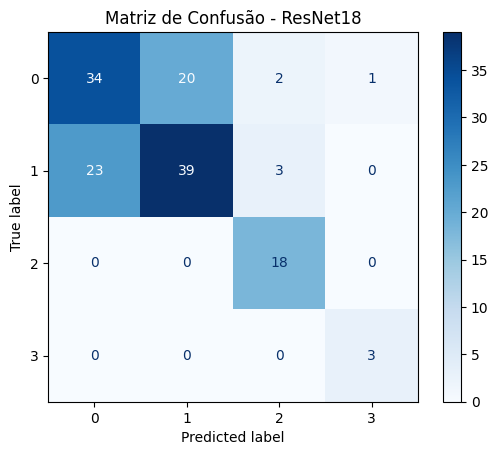

              precision    recall  f1-score   support

           0       0.60      0.60      0.60        57
           1       0.66      0.60      0.63        65
           2       0.78      1.00      0.88        18
           3       0.75      1.00      0.86         3

    accuracy                           0.66       143
   macro avg       0.70      0.80      0.74       143
weighted avg       0.65      0.66      0.65       143



In [8]:
# 📊 Avaliação no test
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])
test_ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), transform=test_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
test_correct = 0
test_total = 0
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100. * test_correct / test_total
print(f'🎯 Test Accuracy: {test_acc:.2f}%')

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1', '2', '3'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão - ResNet18")
plt.show()

print(classification_report(all_labels, all_preds, target_names=['0', '1', '2', '3']))